In [1]:
import os
import numpy
import SimpleITK
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
series_uid = '/ssd2/zhangwd/data/brain/dual_energy_substraction1/bystudy/1.3.12.2.1107.5.1.4.60320.30000016072900171834200000026/1.3.12.2.1107.5.99.2.9594.30000016072913081812500000799'

In [3]:
reader = SimpleITK.ImageSeriesReader()
filenamesDICOM = reader.GetGDCMSeriesFileNames(series_uid)
reader.SetFileNames(filenamesDICOM)
imgOriginal = reader.Execute()

In [4]:
imgOriginal

<SimpleITK.SimpleITK.Image; proxy of <Swig Object of type 'std::vector< itk::simple::Image >::value_type *' at 0x7f41846fc660> >

In [5]:
idxSlice = 212
imgOriginal = imgOriginal[:,:,idxSlice]

In [6]:
imgOriginal

<SimpleITK.SimpleITK.Image; proxy of <Swig Object of type 'std::vector< itk::simple::Image >::value_type *' at 0x7f40e4e3e210> >

In [7]:
def sitk_show(img, title=None, margin=0.05, dpi=50 ):
    nda = SimpleITK.GetArrayFromImage(img)
    spacing = img.GetSpacing()
    figsize = (1 + margin) * nda.shape[0] / dpi, (1 + margin) * nda.shape[1] / dpi
    extent = (0, nda.shape[1]*spacing[1], nda.shape[0]*spacing[0], 0)
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_axes([margin, margin, 1 - 2*margin, 1 - 2*margin])

    plt.set_cmap("gray")
    ax.imshow(nda,extent=extent,interpolation=None)
    
    if title:
        plt.title(title)
    
    plt.show()

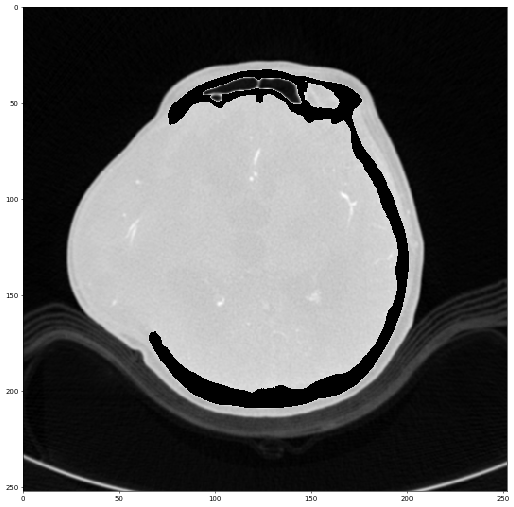

In [8]:
sitk_show(imgOriginal)

In [9]:
imgSmooth = SimpleITK.CurvatureFlow(image1=imgOriginal,
                                    timeStep=0.125,
                                    numberOfIterations=5)

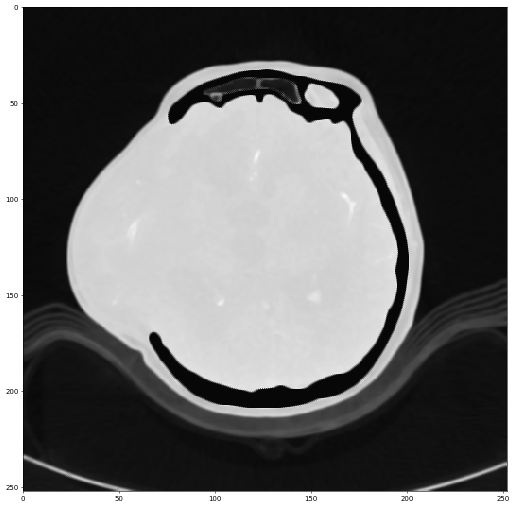

In [10]:
sitk_show(imgSmooth)

In [22]:
labelWhiteMatter = 1

lstSeeds = [(341,200)]

imgWhiteMatter = SimpleITK.ConnectedThreshold(image1=imgSmooth, 
                                              seedList=lstSeeds, 
                                              lower=100, 
                                              upper=500,
                                              replaceValue=labelWhiteMatter)

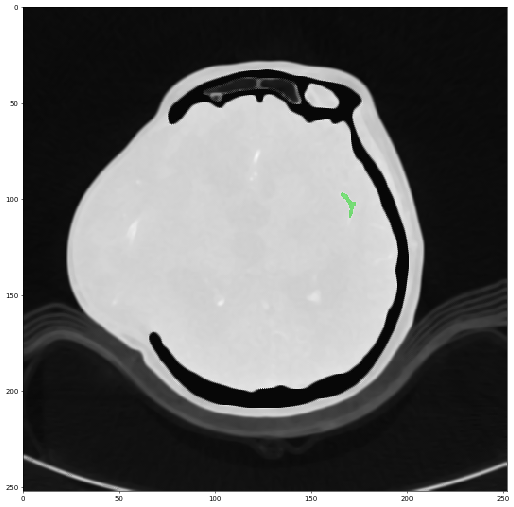

In [23]:
# Rescale 'imgSmooth' and cast it to an integer type to match that of 'imgWhiteMatter'
imgSmoothInt = SimpleITK.Cast(SimpleITK.RescaleIntensity(imgSmooth), imgWhiteMatter.GetPixelID())

# Use 'LabelOverlay' to overlay 'imgSmooth' and 'imgWhiteMatter'
sitk_show(SimpleITK.LabelOverlay(imgSmoothInt, imgWhiteMatter))

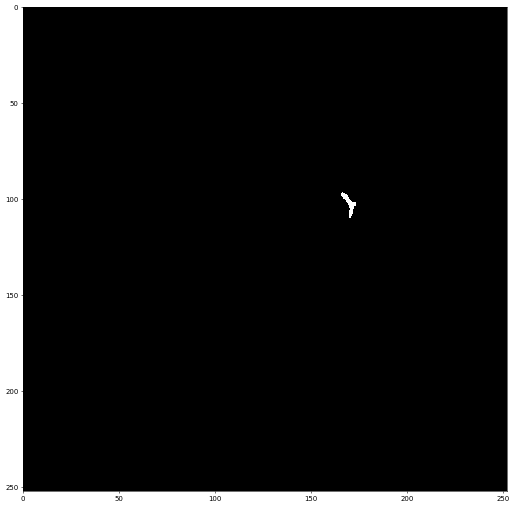

In [24]:
sitk_show(imgWhiteMatter)